module imported sucessfully.
data loaded and dataframe created successfully...
------------------------------------------------------------
dataset is : 
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4       

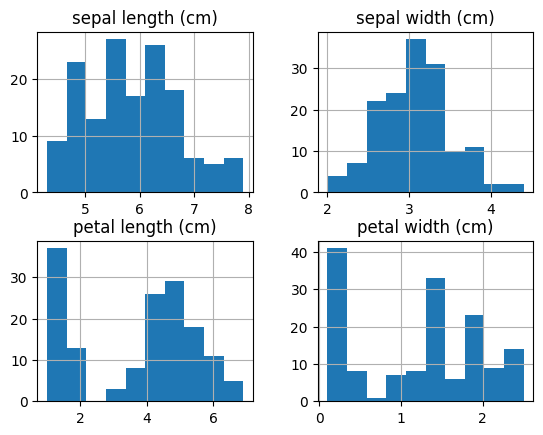

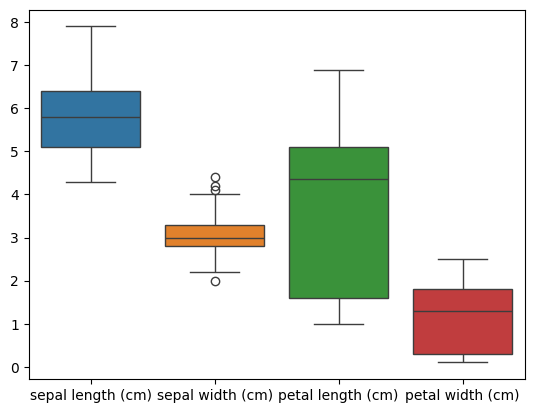

In [20]:
# demonstration of loop and vectorizatioin for missing values, detecet adn remove outliers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
print('module imported sucessfully.')

# load the data
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
print('data loaded and dataframe created successfully...')
print('------------------------------------------------------------')

# preprocessing
print('dataset is : ')
print(df)
print(df.head(10))
print(df.tail(5))
df.shape
df.info()
df.columns
print('duplicates records are :')
print(df.duplicated())
print()
print('null records are :')
print(df.isnull().sum())
print('statistical information of dataset is : ')
print(df.describe())

# outlier detection

print('outliers are : ')
Q1 = df.quantile(0.25)
print('Q1 is :',Q1)
Q3 = df.quantile(0.75)
print('Q3 is :',Q3)
IQR = Q3 - Q1
print('IQR is :',IQR)
outliers = df[~((df < Q1 - 1.5 *  IQR) | (df > Q3 + 1.5 * IQR)).any(axis=1)]
print(outliers)

# create a missing value
print('missing value identification demonstration')
df.iloc[0,0] = None
# for loop
df.info

print('fill it')
for col in df.columns:
    df[col].fillna(df[col].mean())
# Vectorized
print('vectorized')
df = df.fillna(df.mean())
print(df.info)

# visualization
df.hist()
plt.show()

sns.boxplot(data=df)
plt.show()